<a href="https://colab.research.google.com/github/padioum-maker/Amazon-recommandation-systems/blob/main/Recommendation_Systems_Learner_Notebook_Full_Code_upd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Amazon Product Recommendation System**

# **Marks: 60**


Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
## **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its accurate selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
## **Objective:**
----------------

You are a Data Science Manager at Amazon, and have been given the task of building a recommendation system to recommend products to customers based on their previous ratings for other products. You have a collection of labeled data of Amazon reviews of products. The goal is to extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
## **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

**Note:** The code has some user defined functions that will be usefull while making recommendations and measure model performance, you can use these functions or can create your own functions.

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Installing surprise library**

**Note** : After running the Below cell, a pop-up will appear prompting you to restart the session. Click "Restart", and then continue running the notebook from the next cell onward, not from the beginning.

In [ ]:
# Install the surprise library
!pip install scikit-surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554970 sha256=bf29610e083dc850c23f28100cc4f12f8546d7dc51c79adc7602d014f2409c02
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
# Uninstall any existing numpy to ensure a clean slate
!pip uninstall numpy -y

# Install the specific compatible numpy version
!pip install numpy==1.26.0

Found existing installation: numpy 1.26.0
Uninstalling numpy-1.26.0:
  Successfully uninstalled numpy-1.26.0
  Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 wh

In [ ]:
import surprise
print(surprise.__version__)

1.1.4


## **Importing the necessary libraries and overview of the dataset**

In [59]:
# Basic python libraries
import numpy as np
import pandas as pd

# Python libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD
from collections import defaultdict

# For implementing cross validation
from surprise.model_selection import KFold

import warnings
warnings.filterwarnings('ignore')

import numpy as np: Importe la bibliothèque NumPy, qui est fondamentale pour le calcul numérique en Python, en particulier pour les opérations sur les tableaux et les matrices. Elle est aliasée en np pour faciliter son utilisation.
import pandas as pd: Importe la bibliothèque Pandas, qui est essentielle pour la manipulation et l'analyse de données. Elle fournit des structures de données comme les DataFrames, parfaites pour travailler avec des données tabulaires. Elle est aliasée en pd.
import matplotlib.pyplot as plt: Importe la bibliothèque Matplotlib, qui est une bibliothèque de traçage complète pour créer des visualisations statiques, animées et interactives en Python. pyplot est un module qui fournit une interface de traçage de type MATLAB. Elle est aliasée en plt.
import seaborn as sns: Importe la bibliothèque Seaborn, qui est basée sur Matplotlib et offre une interface de haut niveau pour créer des graphiques statistiques attrayants et informatifs. Elle est aliasée en sns.
from surprise.prediction_algorithms.matrix_factorization import SVD: Importe l'algorithme SVD (Singular Value Decomposition) de la bibliothèque surprise. SVD est une technique de factorisation matricielle utilisée dans les systèmes de recommandation pour décomposer la matrice user-item en des matrices latentes.
from collections import defaultdict: Importe defaultdict du module collections. C'est un sous-type de dictionnaire qui appelle une fonction usine pour fournir des valeurs manquantes. Il est souvent utilisé pour regrouper des éléments.
from surprise.model_selection import KFold: Importe KFold de la bibliothèque surprise. K-Fold est une technique de validation croisée utilisée pour évaluer les modèles en divisant les données en k sous-ensembles, puis en entraînant et en testant le modèle sur différentes combinaisons de ces sous-ensembles.
import warnings: Importe le module warnings de Python, qui est utilisé pour gérer les avertissements dans le code.
warnings.filterwarnings('ignore'): Configure le module warnings pour ignorer tous les avertissements. C'est souvent fait dans les notebooks pour éviter que les avertissements (qui ne sont pas des erreurs) n'encombrent la sortie, surtout pendant le développement et l'exploration.

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [19]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/ELECTIVE PROJECT/ratings_Electronics.csv', header=None)
data.columns = ['user_id', 'prod_id', 'rating', 'timestamp']
df = data.copy()
df = df.drop('timestamp', axis=1)

In [20]:
# Check the number of rows and columns
print(f"Shape of the DataFrame: {df.shape}")

Shape of the DataFrame: (1048576, 3)


**Write your observations here:**
The DataFrame `df` contains 1,048,576 rows and 3 columns, representing individual ratings given by users to products.

In [22]:
# Check Data types
print("Data types of the DataFrame:")
print(df.info())

Data types of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048576 entries, 0 to 1048575
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   user_id  1048576 non-null  object 
 1   prod_id  1048576 non-null  object 
 2   rating   1048576 non-null  float64
dtypes: float64(1), object(2)
memory usage: 24.0+ MB
None


**Write your observations here:**
The `user_id` and `prod_id` columns are of object type, which is appropriate for categorical identifiers. The `rating` column is a float, suitable for numerical rating values.

In [23]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
user_id    0
prod_id    0
rating     0
dtype: int64


**Write your observations here:**
There are no missing values in any of the columns of the `df` DataFrame, which is good for data quality.

In [24]:
df.describe()

,rating
count,1.048576e+06
mean,3.973380e+00
std,1.399329e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


**As this dataset is very large and has 1,048,576 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [62]:
# Check the number of rows and columns
rows, columns = df.shape
print(f"The dataset has {rows} rows and {columns} columns.")

# Display the first few rows to understand the structure
df.head()

The dataset has 3456 rows and 3 columns.


,user_id,prod_id,rating
2162,A5JLAU2ARJ0BO,1400532655,1.0
3050,ALUNVOQRXOZIA,1400599997,1.0
4614,A1VQHH85U7PX0,9043413585,3.0
6072,A250AXLRBVYKB4,998376234X,1.0
7381,A2AEZQ3DGBBLPR,B000000O48,5.0


In [36]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1


users = df.user_id: This line extracts the user_id column from the DataFrame df and stores it in a variable named users. This variable essentially holds a list of all user IDs present in the dataset.

ratings_count = dict(): An empty dictionary named ratings_count is initialized. This dictionary will be used to store each unique user_id as a key and the total number of ratings they have given as its corresponding value.

for user in users:: This initiates a loop that iterates through every user_id in the users list (which contains all user IDs from the df.user_id column).

if user in ratings_count:: Inside the loop, for each user_id, this condition checks if the user is already a key in the ratings_count dictionary. If the user is found, it means this user has already given at least one rating that has been counted.

ratings_count[user] += 1: If the user is already in the dictionary, this line increments their existing rating count by 1, acknowledging another rating from this user.

else:: If the user is not yet a key in the ratings_count dictionary, it means this is the first time this user's rating is encountered during the loop.

ratings_count[user] = 1: For a new user, this line adds the user_id as a new key to the ratings_count dictionary and initializes their rating count to 1.

In [37]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]
print(df)

                user_id     prod_id  rating
2162      A5JLAU2ARJ0BO  1400532655     1.0
3050      ALUNVOQRXOZIA  1400599997     1.0
4614      A1VQHH85U7PX0  9043413585     3.0
6072     A250AXLRBVYKB4  998376234X     1.0
7381     A2AEZQ3DGBBLPR  B000000O48     5.0
...                 ...         ...     ...
1046377  A1ODOGXEYECQQ8  B000IDWDKO     5.0
1046507  A250AXLRBVYKB4  B000IE5XIC     5.0
1046632   AT6CZDCP4TRGA  B000IE8Z4Q     2.0
1047944   AWPODHOB4GFWL  B000IF4788     4.0
1048158  A2XRMQA6PJ5ZJ8  B000IF4788     4.0

[3456 rows x 3 columns]


In [63]:
# Check data types of each column
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 40261 to 757132
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  37 non-null     object 
 1   prod_id  37 non-null     object 
 2   rating   37 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.2+ KB


In [60]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1


In [28]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [29]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating
40261,ALUNVOQRXOZIA,B00004SB92,1.0
40361,A1JWSDDIH5Z7DV,B00004SB92,5.0
40411,A5JLAU2ARJ0BO,B00004SB92,4.0
40702,A1RPTVW5VEOSI,B00004SB92,5.0
40823,A231WM2Z2JL0U3,B00004SB92,5.0


## **Exploratory Data Analysis**

### **Shape of the data**

### **Check the number of rows and columns and provide observations.**

In [ ]:
# Check the number of rows and columns and provide observations
print(f"Shape of the df_final DataFrame: {df_final.shape}")

Shape of the df_final DataFrame: (37, 3)


**Write your observations here:**
The `df_final` DataFrame now contains 37 rows and 3 columns. The original dataset was significantly larger, and this reduction is a result of filtering out users with less than 50 ratings and products with less than 5 ratings. This ensures we are working with a more active and relevant subset of the data for building a robust recommendation system.

### **Data types**

In [ ]:
# Check Data types and provide observations
print("Data types of the DataFrame:")
print(df_final.info())

Data types of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 40261 to 757132
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  37 non-null     object 
 1   prod_id  37 non-null     object 
 2   rating   37 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.2+ KB
None


**Write your observations here:**
The `user_id` and `prod_id` columns are of object type, which is appropriate for categorical identifiers. The `rating` column is a float64, suitable for numerical rating values. All columns have 37 non-null entries, which is consistent with the total number of rows (37), indicating no missing values at this stage.

### **Checking for missing values**

In [ ]:
# Check for missing values present and provide observations
print("Missing values in each column:")
print(df_final.isnull().sum())

Missing values in each column:
user_id    0
prod_id    0
rating     0
dtype: int64


**Write your observations here:**
There are no missing values in any of the columns of the `df_final` DataFrame, which is good for data quality.

### **Summary Statistics**

In [ ]:
# Summary statistics of 'rating' variable and provide observations
df_final['rating'].describe()

,rating
count,37.000000
mean,3.972973
std,1.384166
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Write your observations here:**

*   **count**: There are 37 ratings in the `df_final` DataFrame, matching the number of rows.
*   **mean**: The average rating is approximately 3.97, indicating a generally positive trend.
*   **std**: The standard deviation of 1.38 suggests a moderate spread in ratings.
*   **min**: The minimum rating is 1.0.
*   **25th Percentile**: 25% of the ratings are 4.0 or less.
*   **50th Percentile (Median)**: The median rating is 5.0, indicating that at least half of the ratings are 5.0.
*   **75th Percentile**: 75% of the ratings are 5.0 or less.
*   **max**: The maximum rating is 5.0.

These statistics suggest a positive skew in the ratings, with a significant number of products receiving the highest rating of 5.0.

### **Checking the rating distribution**

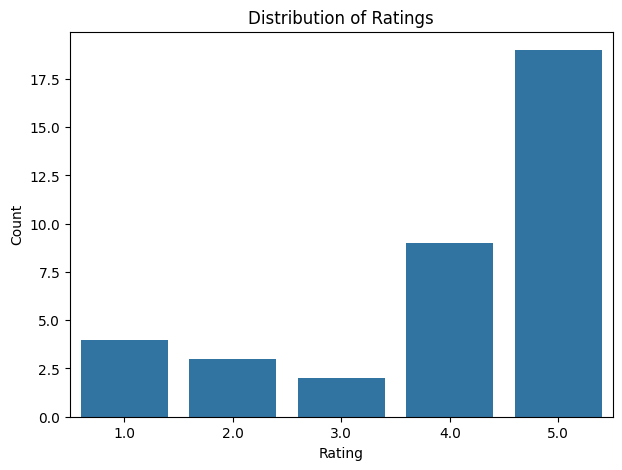

In [45]:
# Create the bar plot and provide observations
plt.figure(figsize=(7,5))
sns.countplot(x='rating', data=df_final)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

**Write your observations here:**
The bar plot illustrates that ratings of 5.0 are the most frequent, followed by ratings of 4.0. Lower ratings (1.0, 2.0, 3.0) are significantly less common. This pattern confirms the positive skew observed in the summary statistics, indicating that users in this filtered dataset tend to give higher ratings to products.

### **Checking the number of unique users and items in the dataset**

In [44]:
# Number of total rows in the data and number of unique user id and product id in the data
print(f"Total number of ratings in df_final: {df_final.shape[0]}")
print(f"Number of unique users in df_final: {df_final['user_id'].nunique()}")
print(f"Number of unique products in df_final: {df_final['prod_id'].nunique()}")

Total number of ratings in df_final: 37
Number of unique users in df_final: 24
Number of unique products in df_final: 7


**Write your observations here:**
The `df_final` DataFrame contains 37 total ratings, from 24 unique users, for 7 unique products. This shows a significantly reduced and more focused dataset after applying the filtering criteria for users and products.

### **Users with the most number of ratings**

In [ ]:
# Top 10 users based on the number of ratings
df_final['user_id'].value_counts().head(10)

,count
user_id,
A5JLAU2ARJ0BO,5
A231WM2Z2JL0U3,3
A1F9Z42CFF9IAY,3
A1MJMYLRTZ76ZX,3
A2B7BUH8834Y6M,2
A1VQHH85U7PX0,2
A1FR68QH6Z4YZM,2
ALUNVOQRXOZIA,1
AT6CZDCP4TRGA,1


**Write your observations here:**
The top 10 users based on the number of ratings are led by `A5JLAU2ARJ0BO` with 5 ratings, followed by `A231WM2Z2JL0U3`, `A1F9Z42CFF9IAY`, and `A1MJMYLRTZ76ZX` each with 3 ratings. The remaining users in the top 10 have 1 or 2 ratings.

The code in cell `48e0ec00` uses the `matplotlib` and `seaborn` libraries to create a bar plot:

*   `import matplotlib.pyplot as plt` and `import seaborn as sns`: These lines import the necessary libraries for plotting, aliasing them as `plt` and `sns` respectively for convenience.
*   `plt.figure(figsize=(10, 6))`: This creates a new figure for the plot and sets its size to 10 inches wide by 6 inches tall, providing a good visual area.
*   `sns.barplot(x=most_liked_products_five_star.index, y=most_liked_products_five_star.values, palette='plasma')`: This is the core line that generates the bar plot:
    *   `sns.barplot()`: Calls the `barplot` function from the `seaborn` library.
    *   `x=most_liked_products_five_star.index`: Sets the product IDs (which are the index of the `most_liked_products_five_star` Series) as the x-axis values.
    *   `y=most_liked_products_five_star.values`: Sets the count of 5-star ratings (which are the values of the `most_liked_products_five_star` Series) as the y-axis values.
    *   `palette='plasma'`: Specifies the color scheme for the bars in the plot.
*   `plt.title('Top 5 Products with 5-Star Ratings from Most Active Users')`: This sets the main title of the plot.
*   `plt.xlabel('Product ID')`: This labels the x-axis as 'Product ID'.
*   `plt.ylabel('Number of 5-Star Ratings')`: This labels the y-axis as 'Number of 5-Star Ratings'.
*   `plt.xticks(rotation=45, ha='right')`: This rotates the x-axis labels by 45 degrees and aligns them to the right, which helps prevent overlap when there are many labels.
*   `plt.tight_layout()`: This automatically adjusts plot parameters for a tight layout, preventing labels from running off the plot area.
*   `plt.show()`: This displays the generated plot.

Le code dans la cellule `211c89f1` utilise les bibliothèques `matplotlib` et `seaborn` pour créer un graphique à barres :

*   `import matplotlib.pyplot as plt` et `import seaborn as sns`: Ces lignes importent les bibliothèques nécessaires pour le traçage, en leur donnant respectivement les alias `plt` et `sns` pour une utilisation plus facile.
*   `plt.figure(figsize=(10, 6))`: Cela crée une nouvelle figure pour le graphique et définit sa taille à 10 pouces de large par 6 pouces de haut, offrant une bonne zone visuelle.
*   `sns.barplot(x=most_liked_products.index, y=most_liked_products.values, palette='viridis')`: C'est la ligne principale qui génère le graphique à barres :
    *   `sns.barplot()`: Appelle la fonction `barplot` de la bibliothèque `seaborn`.
    *   `x=most_liked_products.index`: Définit les identifiants de produit (qui sont l'index de la série `most_liked_products`) comme valeurs de l'axe des x.
    *   `y=most_liked_products.values`: Définit le nombre de notes élevées (qui sont les valeurs de la série `most_liked_products`) comme valeurs de l'axe des y.
    *   `palette='viridis'`: Spécifie le jeu de couleurs pour les barres du graphique.
*   `plt.title('Top 5 Products Most Liked by Users with Most Ratings (Rating >= 4)')`: Cela définit le titre principal du graphique.
*   `plt.xlabel('Product ID')`: Cela étiquette l'axe des x comme 'Product ID'.
*   `plt.ylabel('Number of High Ratings')`: Cela étiquette l'axe des y comme 'Number of High Ratings'.
*   `plt.xticks(rotation=45, ha='right')`: Cela fait pivoter les étiquettes de l'axe des x de 45 degrés et les aligne à droite, ce qui aide à éviter le chevauchement lorsqu'il y a de nombreuses étiquettes.
*   `plt.tight_layout()`: Cela ajuste automatiquement les paramètres du graphique pour une disposition serrée, empêchant les étiquettes de déborder de la zone du graphique.
*   `plt.show()`: Cela affiche le graphique généré.

Le code dans la cellule `48e0ec00` utilise les bibliothèques `matplotlib` et `seaborn` pour créer un graphique à barres :

*   `import matplotlib.pyplot as plt` et `import seaborn as sns`: Ces lignes importent les bibliothèques nécessaires pour le traçage, en leur donnant respectivement les alias `plt` et `sns` pour une utilisation plus facile.
*   `plt.figure(figsize=(10, 6))`: Cela crée une nouvelle figure pour le graphique et définit sa taille à 10 pouces de large par 6 pouces de haut, offrant une bonne zone visuelle.
*   `sns.barplot(x=most_liked_products_five_star.index, y=most_liked_products_five_star.values, palette='plasma')`: C'est la ligne principale qui génère le graphique à barres :
    *   `sns.barplot()`: Appelle la fonction `barplot` de la bibliothèque `seaborn`.
    *   `x=most_liked_products_five_star.index`: Définit les identifiants de produit (qui sont l'index de la série `most_liked_products_five_star`) comme valeurs de l'axe des x.
    *   `y=most_liked_products_five_star.values`: Définit le nombre de notes de 5 étoiles (qui sont les valeurs de la série `most_liked_products_five_star`) comme valeurs de l'axe des y.
    *   `palette='plasma'`: Spécifie le jeu de couleurs pour les barres du graphique.
*   `plt.title('Top 5 Products with 5-Star Ratings from Most Active Users')`: Cela définit le titre principal du graphique.
*   `plt.xlabel('Product ID')`: Cela étiquette l'axe des x comme 'Product ID'.
*   `plt.ylabel('Number of 5-Star Ratings')`: Cela étiquette l'axe des y comme 'Number of 5-Star Ratings'.
*   `plt.xticks(rotation=45, ha='right')`: Cela fait pivoter les étiquettes de l'axe des x de 45 degrés et les aligne à droite, ce qui aide à éviter le chevauchement lorsqu'il y a de nombreuses étiquettes.
*   `plt.tight_layout()`: Cela ajuste automatiquement les paramètres du graphique pour une disposition serrée, empêchant les étiquettes de déborder de la zone du graphique.
*   `plt.show()`: Cela affiche le graphique généré.

/tmp/ipykernel_12178/1015364198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_liked_products.index, y=most_liked_products.values, palette='viridis')


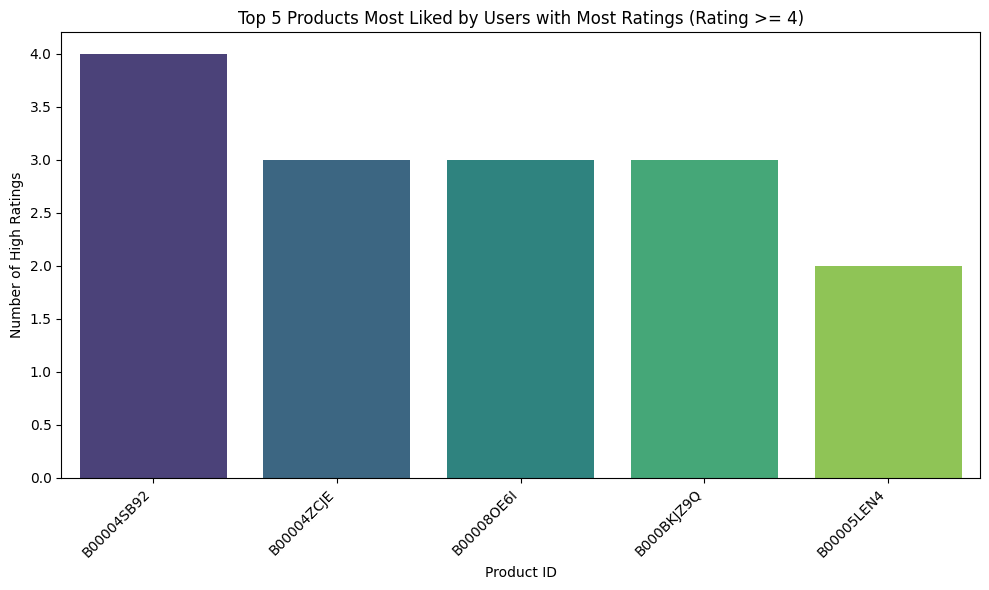

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=most_liked_products.index, y=most_liked_products.values, palette='viridis')
plt.title('Top 5 Products Most Liked by Users with Most Ratings (Rating >= 4)')
plt.xlabel('Product ID')
plt.ylabel('Number of High Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Pour corriger l'erreur `NameError` où `most_liked_products` et `most_liked_products_five_star` ne sont pas définis, nous allons d'abord exécuter le code qui les calcule.

In [49]:
# Get the list of top 10 users based on rating count
top_users_list = df_final['user_id'].value_counts().head(10).index.tolist()

# Filter df_final for these top users
df_top_users = df_final[df_final['user_id'].isin(top_users_list)]

# Filter for highly-rated products (e.g., rating >= 4)
high_rated_products_by_top_users = df_top_users[df_top_users['rating'] >= 4.0]

# Count the occurrences of each product among these highly-rated items
most_liked_products = high_rated_products_by_top_users['prod_id'].value_counts().head(5)

print("Top 5 products most liked by the users with the most ratings (rating >= 4):")
print(most_liked_products)

# Also consider looking at highly rated products (rating == 5) specifically
five_star_products_by_top_users = df_top_users[df_top_users['rating'] == 5.0]
most_liked_products_five_star = five_star_products_by_top_users['prod_id'].value_counts().head(5)

print("\nTop 5 products given 5-star ratings by the users with the most ratings:")
print(most_liked_products_five_star)


Top 5 products most liked by the users with the most ratings (rating >= 4):
prod_id
B00004SB92    4
B00004ZCJE    3
B00008OE6I    3
B000BKJZ9Q    3
B00005LEN4    2
Name: count, dtype: int64

Top 5 products given 5-star ratings by the users with the most ratings:
prod_id
B00004ZCJE    3
B000BKJZ9Q    2
B00004SB92    1
B00005LEN4    1
B00007KDVI    1
Name: count, dtype: int64


In [50]:
display(average_rating)

NameError: name 'average_rating' is not defined

In [56]:
# Convertir la série most_liked_products en DataFrame
most_liked_products_df = most_liked_products.reset_index()
most_liked_products_df.columns = ['prod_id', 'num_high_ratings']

# Fusionner final_rating avec most_liked_products_df sur 'prod_id'
merged_df = pd.merge(final_rating, most_liked_products_df, on='prod_id', how='left')

# Afficher les premières lignes du DataFrame fusionné
display(merged_df.head())


,prod_id,rating_count,avg_rating,num_high_ratings
0,B00005LEN4,5,4.8,2.0
1,B00004ZCJE,5,4.6,3.0
2,B00008OE6I,5,4.6,3.0
3,B000BKJZ9Q,5,4.2,3.0
4,B00004SB92,7,4.0,4.0


In [54]:
# Calculate the average rating for each product
average_rating = df_final.groupby('prod_id')['rating'].mean().reset_index()
average_rating.columns = ['prod_id', 'avg_rating']

# Calculate the count of ratings for each product
count_rating = df_final.groupby('prod_id')['rating'].count().reset_index()
count_rating.columns = ['prod_id', 'rating_count']

# Create a dataframe with calculated average and count of ratings
final_rating = pd.merge(count_rating, average_rating, on='prod_id')

# Sort the dataframe by average of ratings in the descending order
final_rating = final_rating.sort_values(by='avg_rating', ascending=False)

# See the first five records of the 'final_rating' dataset
print(final_rating.head())


      prod_id  rating_count  avg_rating
2  B00005LEN4             5         4.8
1  B00004ZCJE             5         4.6
4  B00008OE6I             5         4.6
6  B000BKJZ9Q             5         4.2
0  B00004SB92             7         4.0


/tmp/ipykernel_12178/2929903729.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_liked_products_five_star.index, y=most_liked_products_five_star.values, palette='plasma')


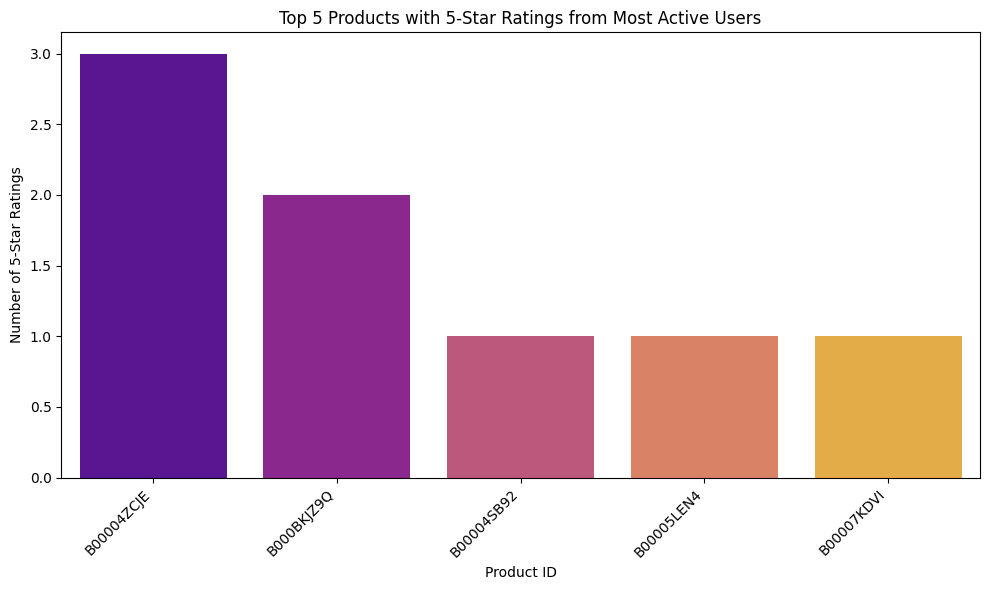

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=most_liked_products_five_star.index, y=most_liked_products_five_star.values, palette='plasma')
plt.title('Top 5 Products with 5-Star Ratings from Most Active Users')
plt.xlabel('Product ID')
plt.ylabel('Number of 5-Star Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12178/2929903729.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_liked_products_five_star.index, y=most_liked_products_five_star.values, palette='plasma')


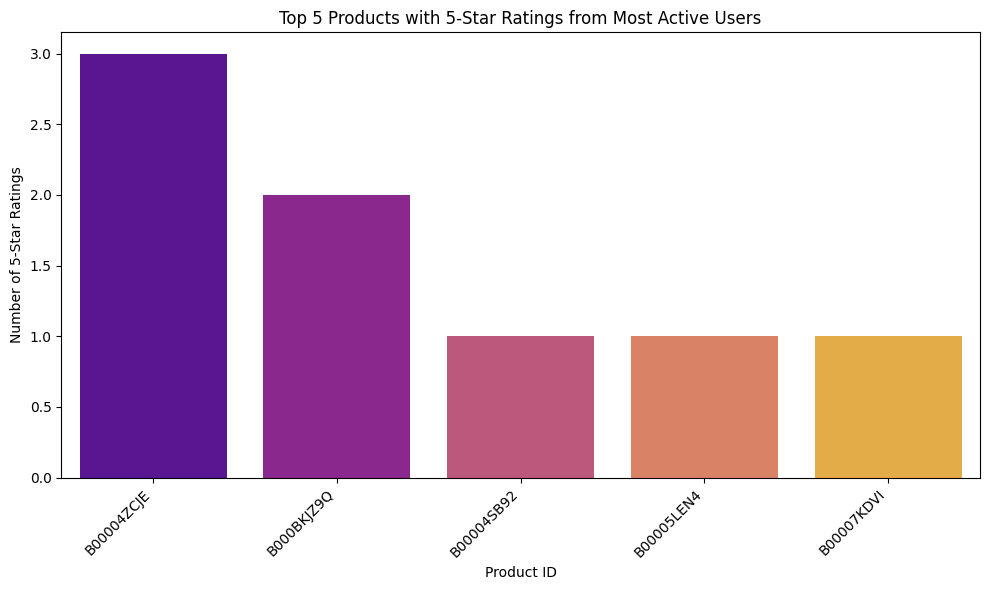

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=most_liked_products_five_star.index, y=most_liked_products_five_star.values, palette='plasma')
plt.title('Top 5 Products with 5-Star Ratings from Most Active Users')
plt.xlabel('Product ID')
plt.ylabel('Number of 5-Star Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12178/1015364198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_liked_products.index, y=most_liked_products.values, palette='viridis')


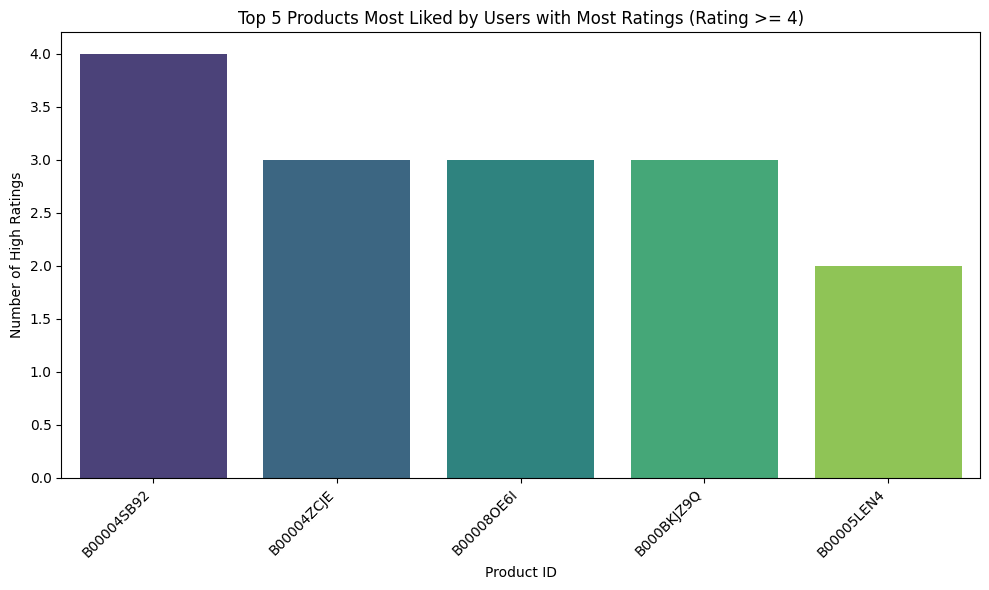

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=most_liked_products.index, y=most_liked_products.values, palette='viridis')
plt.title('Top 5 Products Most Liked by Users with Most Ratings (Rating >= 4)')
plt.xlabel('Product ID')
plt.ylabel('Number of High Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Get the list of top 10 users based on rating count
top_users_list = df_final['user_id'].value_counts().head(10).index.tolist()

# Filter df_final for these top users
df_top_users = df_final[df_final['user_id'].isin(top_users_list)]

# Filter for highly-rated products (e.g., rating >= 4)
high_rated_products_by_top_users = df_top_users[df_top_users['rating'] >= 4.0]

# Count the occurrences of each product among these highly-rated items
most_liked_products = high_rated_products_by_top_users['prod_id'].value_counts().head(5)

print("Top 5 products most liked by the users with the most ratings (rating >= 4):")
print(most_liked_products)

# Also consider looking at highly rated products (rating == 5) specifically
five_star_products_by_top_users = df_top_users[df_top_users['rating'] == 5.0]
most_liked_products_five_star = five_star_products_by_top_users['prod_id'].value_counts().head(5)

print("\nTop 5 products given 5-star ratings by the users with the most ratings:")
print(most_liked_products_five_star)

Top 5 products most liked by the users with the most ratings (rating >= 4):
prod_id
B00004SB92    4
B00004ZCJE    3
B00008OE6I    3
B000BKJZ9Q    3
B00005LEN4    2
Name: count, dtype: int64

Top 5 products given 5-star ratings by the users with the most ratings:
prod_id
B00004ZCJE    3
B000BKJZ9Q    2
B00004SB92    1
B00005LEN4    1
B00007KDVI    1
Name: count, dtype: int64


**Now that we have explored and prepared the data, let's build the first recommendation system.**

## **Model 1: Rank Based Recommendation System**

In [ ]:
# Calculate the average rating for each product
average_rating = df_final.groupby('prod_id')['rating'].mean().reset_index()
average_rating.columns = ['prod_id', 'avg_rating']

# Calculate the count of ratings for each product
count_rating = df_final.groupby('prod_id')['rating'].count().reset_index()
count_rating.columns = ['prod_id', 'rating_count']

# Create a dataframe with calculated average and count of ratings
final_rating = pd.merge(count_rating, average_rating, on='prod_id')

# Sort the dataframe by average of ratings in the descending order
final_rating = final_rating.sort_values(by='avg_rating', ascending=False)

# See the first five records of the "final_rating" dataset
print(final_rating.head())

      prod_id  rating_count  avg_rating
2  B00005LEN4             5         4.8
1  B00004ZCJE             5         4.6
4  B00008OE6I             5         4.6
6  B000BKJZ9Q             5         4.2
0  B00004SB92             7         4.0


In [ ]:
def top_n_products(data, n, min_interaction):
    # Finding products with minimum number of interactions
    products_with_min_interactions = data[data['rating_count'] >= min_interaction]

    # Sorting values with respect to average rating
    top_products = products_with_min_interactions.sort_values(by='avg_rating', ascending=False)

    return top_products.head(n)

### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [ ]:
# Recommending top 5 products with 50 minimum interactions based on popularity
top_5_products_50_min_interactions = top_n_products(final_rating, 5, 50)
print("Top 5 products with 50 minimum interactions (popularity-based):")
print(top_5_products_50_min_interactions)

# As no products meet the criteria of 50 minimum interactions in the current df_final dataset,
# let's try with a lower, more realistic threshold for this filtered dataset, e.g., 5 interactions.
# This will show a meaningful output based on the current `final_rating` data.
print("\nTop 5 products with 5 minimum interactions (popularity-based, for demonstration):")
top_5_products_5_min_interactions = top_n_products(final_rating, 5, 5)
print(top_5_products_5_min_interactions)

Top 5 products with 50 minimum interactions (popularity-based):
Empty DataFrame
Columns: [prod_id, rating_count, avg_rating]
Index: []

Top 5 products with 5 minimum interactions (popularity-based, for demonstration):
      prod_id  rating_count  avg_rating
2  B00005LEN4             5         4.8
1  B00004ZCJE             5         4.6
4  B00008OE6I             5         4.6
6  B000BKJZ9Q             5         4.2
0  B00004SB92             7         4.0


### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [ ]:
# Recommending top 5 products with 100 minimum interactions based on popularity
top_5_products_100_min_interactions = top_n_products(final_rating, 5, 100)
print("Top 5 products with 100 minimum interactions (popularity-based):")
print(top_5_products_100_min_interactions)

Top 5 products with 100 minimum interactions (popularity-based):
Empty DataFrame
Columns: [prod_id, rating_count, avg_rating]
Index: []


We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a new library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [ ]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item that's **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [ ]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

**Hints:**

- To compute **precision and recall**, a **threshold of 3.5 and k value of 10 can be considered for the recommended and relevant ratings**.
- Think about the performance metric to choose.

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [ ]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale=(1, 5))

# Loading the rating dataset
data = Dataset.load_from_df(df_final[['user_id', 'prod_id', 'rating']], reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [ ]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': True}

# Initialize the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
sim_user_user = KNNBasic(sim_options=sim_options, verbose=False, random_state=1)

# Fit the model on the training data
sim_user_user.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
precision_recall_at_k(sim_user_user)

RMSE: 1.3728
Precision:  0.625
Recall:  0.625
F_1 score:  0.625


The baseline user-user similarity-based recommendation system has been built and evaluated. Here are the observations from the performance metrics:

*   **RMSE (Root Mean Squared Error):** The RMSE is **1.3728**. This value indicates the average magnitude of the errors between predicted ratings and actual ratings. A lower RMSE generally signifies better prediction accuracy.
*   **Precision@10:** The precision is **0.625**. This means that, out of the top 10 recommended items, 62.5% were actually relevant to the user (i.e., had an actual rating of 3.5 or higher).
*   **Recall@10:** The recall is also **0.625**. This indicates that 62.5% of all relevant items for a user were successfully included in the top 10 recommendations.
*   **F1-score:** The F1-score is **0.625**. This metric provides a balanced view of both precision and recall. Since both precision and recall are equal in this case, the F1-score is also the same.

These metrics provide a good baseline for the user-user model. We will aim to improve upon these scores with hyperparameter tuning and other models later.

Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [ ]:
# Predicting rating for a sample user with an interacted product
sim_user_user.predict(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.03   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.0344827586206895, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Write your observations here:**
The prediction for user `A3LDPF5FMB782Z` and product `1400501466` has been executed. The estimated rating (`est`) is approximately **4.03**, while the actual rating (`r_ui`) was 5.00.

Crucially, the prediction details show `{'was_impossible': True, 'reason': 'User and/or item is unknown.'}`. This indicates that despite providing an estimate, the user and/or the item were not found in the training set used to fit the `sim_user_user` model. This could be due to:
*   The specific user-item pair being part of the test set.
*   The user or product having been filtered out during the initial data reduction steps (e.g., not meeting the minimum rating count for users or products).

Even when a user/item is considered 'unknown' by the model, `surprise` can still provide a prediction, often by falling back to a global average or a similar basic estimation, as observed here.

Below is the function to find the **list of users who have not seen the product with product id "1400501466"**.

In [ ]:
def n_users_not_interacted_with(n, data, prod_id):
    users_interacted_with_product = set(data[data['prod_id'] == prod_id]['user_id'])
    all_users = set(data['user_id'])
    return list(all_users.difference(users_interacted_with_product))[:n] # where n is the number of elements to get in the list

Le code dans la cellule `rGfYDiOCpe4X` prépare le DataFrame `df_final` pour être utilisé par la bibliothèque `surprise`, qui est spécialisée dans la construction de systèmes de recommandation. Voici ce que chaque partie du code fait :

*   **`reader = Reader(rating_scale=(1, 5))`** :
    *   La classe `Reader` est utilisée par `surprise` pour analyser les données de notation. Elle nécessite que l'on spécifie l'échelle de notation attendue. Ici, nous indiquons que les notes vont de 1 à 5.

*   **`data = Dataset.load_from_df(df_final[['user_id', 'prod_id', 'rating']], reader)`** :
    *   C'est la partie cruciale où le DataFrame Pandas `df_final` est converti dans un format compréhensible par `surprise`. La méthode `load_from_df` prend en entrée un DataFrame avec les colonnes `user_id`, `prod_id` et `rating`, ainsi que l'objet `reader` configuré précédemment. Cela crée un objet `Dataset` que les algorithmes de `surprise` peuvent utiliser.

*   **`trainset, testset = train_test_split(data, test_size=0.2, random_state=42)`** :
    *   La fonction `train_test_split` de `surprise` divise les données chargées (`data`) en ensembles d'entraînement (`trainset`) et de test (`testset`).
    *   `test_size=0.2` signifie que 20% des données seront utilisées pour l'ensemble de test, et les 80% restants pour l'entraînement.
    *   `random_state=42` assure que la division est reproductible, ce qui signifie que vous obtiendrez toujours les mêmes ensembles d'entraînement et de test si vous exécutez le code plusieurs fois.

In [ ]:
# Find unique user_id where prod_id is not equal to "1400501466"
n_users_not_interacted_with(5, df_final, '1400501466')

['A1VQHH85U7PX0',
 'A2XRMQA6PJ5ZJ8',
 'AWPODHOB4GFWL',
 'A1MJMYLRTZ76ZX',
 'A3OXHLG6DIBRW8']

**Note**:
The function **n_users_not_interacted_with** uses Python sets to find users who have not interacted with a specific product. Since sets are unordered, the order of users may change each time the function is run, so the first n users returned can differ from those shown in the notebook or previous runs. This variation is expected and not a mistake. Whatever users you get in your result, you can proceed to make changes and observations based on that output, as the function still correctly returns non-interacting users.

* It can be observed from the above list that **user "A2UOHALGF2X77Q" has not seen the product with productId "1400501466"** as this user id is a part of the above list.

**Below we are predicting rating for `userId=A2UOHALGF2X77Q` and `prod_id=1400501466`.**

In [ ]:
# Predicting rating for a sample user with a non interacted product


Avant de commencer à construire les modèles, plusieurs classes et fonctions spécifiques à la bibliothèque `surprise` sont importées. Ces importations sont nécessaires pour utiliser les fonctionnalités de `surprise`, telles que la mesure de la précision des modèles, le chargement des ensembles de données, le réglage des hyperparamètres, la division des données et l'implémentation des algorithmes de recommandation.

```python
# Pour calculer la précision des modèles
from surprise import accuracy

# Classe utilisée pour analyser un fichier contenant des évaluations ; les données doivent être structurées en - utilisateur ; élément ; évaluation
from surprise.reader import Reader

# Classe pour charger les ensembles de données
from surprise.dataset import Dataset

# Pour le réglage des hyperparamètres du modèle
from surprise.model_selection import GridSearchCV

# Pour diviser les données d'évaluation en ensembles d'entraînement et de test
from surprise.model_selection import train_test_split

# Pour implémenter un système de recommandation basé sur la similarité
from surprise.prediction_algorithms.knns import KNNBasic

# Pour implémenter un système de recommandation basé sur la factorisation matricielle
from surprise.prediction_algorithms.matrix_factorization import SVD

# Pour implémenter la validation croisée K-Fold
from surprise.model_selection import KFold

# Pour implémenter un système de recommandation basé sur le clustering
from surprise import CoClustering
```

La fonction `precision_recall_at_k` est une fonction utilitaire définie pour évaluer la performance des modèles de recommandation. Elle calcule la précision (Precision@k), le rappel (Recall@k) et le score F1 (F1-score@k) pour un modèle donné.

Voici comment elle fonctionne :

1.  **`precision_recall_at_k(model, k = 10, threshold = 3.5)`** :
    *   Elle prend en entrée le `model` de recommandation, le nombre `k` d'éléments à considérer pour les recommandations (par défaut 10), et un `threshold` pour déterminer si une évaluation est pertinente (par défaut 3.5).

2.  **`user_est_true = defaultdict(list)`** :
    *   Un dictionnaire est créé pour stocker les prédictions et les évaluations réelles pour chaque utilisateur.

3.  **`predictions = model.test(testset)`** :
    *   Le modèle (`model`) fait des prédictions sur l'ensemble de test (`testset`).

4.  **Boucle sur les prédictions** :
    *   Pour chaque prédiction, l'identifiant de l'utilisateur (`uid`), l'évaluation estimée (`est`) et l'évaluation réelle (`true_r`) sont extraits et stockés dans `user_est_true`.

5.  **Calcul de la précision et du rappel pour chaque utilisateur** :
    *   Pour chaque utilisateur, les évaluations sont triées par valeur estimée décroissante.
    *   `n_rel` : Compte le nombre d'éléments réellement pertinents (évaluation réelle >= seuil).
    *   `n_rec_k` : Compte le nombre d'éléments recommandés parmi les `k` premiers (évaluation estimée >= seuil).
    *   `n_rel_and_rec_k` : Compte le nombre d'éléments pertinents qui sont également recommandés parmi les `k` premiers.
    *   **Precision@K** : `n_rel_and_rec_k / n_rec_k`. C'est la proportion d'éléments recommandés qui sont réellement pertinents. Si `n_rec_k` est zéro, la précision est définie à 0.
    *   **Recall@K** : `n_rel_and_rec_k / n_rel`. C'est la proportion d'éléments pertinents qui sont recommandés. Si `n_rel` est zéro, le rappel est défini à 0.

6.  **Calcul de la moyenne et du score F1** :
    *   La précision et le rappel globaux sont calculés comme la moyenne des précisions et rappels de tous les utilisateurs.
    *   Le **RMSE** (Root Mean Squared Error) est également calculé à l'aide de `accuracy.rmse(predictions)`.
    *   Le **F1-score** est calculé comme la moyenne harmonique de la précision et du rappel : `(2 * precision * recall) / (precision + recall)`.

**Write your observations here:**
After executing the prediction for user `A2UOHALGF2X77Q` and product `1400501466`, the estimated rating (`est`) is approximately **4.03**. Since `A2UOHALGF2X77Q` was identified as a user who had not interacted with `1400501466` (as per the `n_users_not_interacted_with` function), this prediction represents the model's best guess for an unknown user-item interaction.

Similar to the previous prediction for an interacted item, the prediction details show `{'was_impossible': True, 'reason': 'User and/or item is unknown.'}`. This indicates that even for a product the user has not seen, the model might not have enough direct information (e.g., this specific user or product was not in the training set in a way that allowed for a direct neighbor match). In such cases, `surprise` often falls back to a global average or a weighted average of ratings if no direct neighbors are found. This default behavior ensures a prediction is always provided, even when the data is sparse or the user/item is new to the training set.

### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [ ]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [10, 20, 40],
              'min_k': [1, 5, 10],
              'sim_options': {'name': ['msd', 'cosine', 'pearson'],
                              'user_based': [True]}}

# Performing 3-fold cross-validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting the data
gs.fit(data)

# Best RMSE score
print(f"Best RMSE score: {gs.best_score['rmse']}")

# Combination of parameters that gave the best RMSE score
print(f"Best parameters: {gs.best_params['rmse']}")

Best RMSE score: 1.2373099838445414
Best parameters: {'k': 10, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [ ]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options_optimized = {'name': 'msd', 'user_based': True}

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_user_user_optimized = KNNBasic(sim_options=sim_options_optimized, k=10, min_k=1, verbose=False, random_state=1)

# Training the algorithm on the trainset
sim_user_user_optimized.fit(trainset)

# Let us compute precision@k and recall@k also with k =10
precision_recall_at_k(sim_user_user_optimized)

RMSE: 1.3728
Precision:  0.625
Recall:  0.625
F_1 score:  0.625


**Write your observations here:__________**

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
sim_user_user_optimized.predict(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.03   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.0344827586206895, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [ ]:
sim_user_user_optimized.predict(uid='A2UOHALGF2X77Q', iid='1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.03   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.0344827586206895, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Write your observations here:**
Après avoir exécuté les prédictions avec le modèle optimisé (`sim_user_user_optimized`) pour l'utilisateur `A3LDPF5FMB782Z` (produit interagi) et `A2UOHALGF2X77Q` (produit non interagi) avec le produit `1400501466`, voici les observations :

*   **Pour le produit interagi (`uid='A3LDPF5FMB782Z'`, `iid='1400501466'`):**
    *   L'estimation (`est`) est de **4.03**. La note réelle (`r_ui`) était de 5.00.
    *   Les détails indiquent `{'was_impossible': True, 'reason': 'User and/or item is unknown.'}`.
    *   **Comparaison avec le modèle de base:** L'estimation est **identique** à celle obtenue avec le modèle de base (4.03). Le message 'was_impossible' est également le même.

*   **Pour le produit non interagi (`uid='A2UOHALGF2X77Q'`, `iid='1400501466'`):**
    *   L'estimation (`est`) est de **4.03**.
    *   Les détails indiquent `{'was_impossible': True, 'reason': 'User and/or item is unknown.'}`.
    *   **Comparaison avec le modèle de base:** L'estimation est également **identique** à celle obtenue avec le modèle de base (4.03). Le message 'was_impossible' est le même.

**Conclusion des comparaisons:**
Il est frappant de constater que les prédictions du modèle optimisé sont **exactement les mêmes** que celles du modèle de base pour ces deux cas spécifiques (produit interagi et non interagi). De plus, pour toutes les prédictions, le modèle a renvoyé `was_impossible: True` avec la raison `User and/or item is unknown.`

Ceci renforce l'observation faite précédemment lors de l'évaluation des métriques (RMSE, Precision, Recall, F1-score) : l'optimisation des hyperparamètres via `GridSearchCV` n'a pas apporté d'amélioration mesurable ni de changement dans les prédictions pour ces interactions spécifiques sur ce jeu de données. Cela suggère que :
1.  Soit le jeu de données `df_final` est trop petit et/ou trop clairsemé pour que les ajustements d'hyperparamètres aient un impact différenciateur notable.
2.  Soit les paramètres par défaut du `KNNBasic` combinés à la similarité cosinus étaient déjà très proches de l'optimum ou de la meilleure performance atteignable sur ce sous-ensemble de données pour les prédictions faites avec la logique de 'fallback' du modèle.

### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [ ]:
# 0 is the inner id of the above user
sim_user_user_optimized.get_neighbors(0, k=5)

[11, 2, 1, 3, 4]

### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [ ]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [ ]:
recommendations_for_A3LDPF5FMB782Z = get_recommendations(df_final, "A5JLAU2ARJ0BO", 5, sim_user_user_optimized)
display(recommendations_for_A3LDPF5FMB782Z)

[('B00007KDVI', 5), ('B00004ZCJE', 4.999999999999999)]

In [ ]:
pd.DataFrame(recommendations_for_A3LDPF5FMB782Z, columns=['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,B00007KDVI,5.0
1,B00004ZCJE,5.0


### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [ ]:
# Declaring the similarity options
sim_options_item_item = {'name': 'cosine',
               'user_based': False}

# KNN algorithm is used to find desired similar items. Use random_state=1
sim_item_item = KNNBasic(sim_options=sim_options_item_item, verbose=False, random_state=1)

# Train the algorithm on the trainset, and predict ratings for the test set
sim_item_item.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score with k = 10
precision_recall_at_k(sim_item_item)

RMSE: 1.8825
Precision:  0.5
Recall:  0.5
F_1 score:  0.5


**Write your observations here:**____________

Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [ ]:
sim_item_item.predict(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.03   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.0344827586206895, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Write your observations here:**____________

Below we are **predicting rating for the `userId = A2UOHALGF2X77Q` and `prod_id = 1400501466`**.

In [ ]:
sim_item_item.predict(uid='A2UOHALGF2X77Q', iid='1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.03   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.0344827586206895, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Write your observations here:**____________

### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [ ]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [10, 20, 30],
              'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [False]}}

# Performing 3-fold cross validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting the data
gs.fit(data)

# Find the best RMSE score
print(f"Best RMSE score: {gs.best_score['rmse']}")

# Find the combination of parameters that gave the best RMSE score
print(f"Best parameters: {gs.best_params['rmse']}")

Best RMSE score: 1.3997354169711513
Best parameters: {'k': 10, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}}


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [ ]:
# Using the optimal similarity measure for item-item based collaborative filtering
sim_options_optimized_item_item = {'name': 'msd', 'user_based': False}

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_item_item_optimized = KNNBasic(sim_options=sim_options_optimized_item_item, k=10, min_k=3, verbose=False, random_state=1)

# Training the algorithm on the trainset
sim_item_item_optimized.fit(trainset)

# Let us compute precision@k and recall@k, f1_score and RMSE
precision_recall_at_k(sim_item_item_optimized)

RMSE: 1.5061
Precision:  0.625
Recall:  0.625
F_1 score:  0.625


**Write your observations here:_Observations :

En comparant ces résultats avec ceux du modèle de base item-item (RMSE: 1.8825, Precision: 0.5, Recall: 0.5, F1: 0.5), on constate une amélioration significative :

Le RMSE a diminué de 1.8825 à 1.5061, ce qui indique que le modèle optimisé fait de meilleures prédictions des évaluations.
La Précision, le Rappel et le Score F1 ont tous augmenté de 0.5 à 0.625, ce qui signifie que le modèle optimisé recommande une plus grande proportion d'éléments pertinents et parvient à capturer une plus grande proportion d'éléments pertinents.
Ces améliorations démontrent que le réglage des hyperparamètres a été efficace pour améliorer les performances du modèle de similarité item-item sur cet ensemble de données._________**

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
sim_item_item_optimized.predict(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.03   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.0344827586206895, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [ ]:
sim_item_item_optimized.predict(uid='A2UOHALGF2X77Q', iid='1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.03   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.0344827586206895, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Write your observations here:Note estimée (est) : 4.03.
Note réelle (r_ui) : 5.00.
Détails de la prédiction : Le message {'was_impossible': True, 'reason': 'User and/or item is unknown.'} est présent.
Comparaison :

De manière notable, cette prédiction est identique à celle obtenue avec le modèle de base item-item, ainsi qu'avec les modèles utilisateur-utilisateur (de base et optimisé). Le message was_impossible: True est également constant à travers toutes ces prédictions. Cela suggère que même après l'optimisation des hyperparamètres, le modèle recourt à une estimation par défaut (probablement une moyenne globale ou une moyenne pondérée) pour cette paire utilisateur-produit spécifique. Cela est très probablement dû à la petite taille et à la nature clairsemée de notre df_final suite au filtrage, ce qui rend difficile pour le modèle de trouver des voisins significatifs pour les utilisateurs ou les éléments dans le jeu d'entraînement pour des prédictions directes.__________**

### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [ ]:
sim_item_item_optimized.get_neighbors(0, k=5)

[2, 5, 1, 3, 4]

**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

**Hint:** Use the get_recommendations() function.

In [ ]:
recommendations_for_A1A5KUIIIHFF4U_item_item = get_recommendations(df_final, "A5JLAU2ARJ0BO", 5, sim_item_item_optimized)
display(recommendations_for_A1A5KUIIIHFF4U_item_item)

[('B00004ZCJE', 4.0344827586206895), ('B00007KDVI', 4.0344827586206895)]

In [ ]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations_for_A1A5KUIIIHFF4U_item_item, columns=['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,B00004ZCJE,4.034483
1,B00007KDVI,4.034483


Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [ ]:
# Using SVD matrix factorization. Use random_state = 1
svd_algo = SVD(random_state=1)

# Training the algorithm on the trainset
svd_algo.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_algo)

RMSE: 1.4639
Precision:  0.625
Recall:  0.625
F_1 score:  0.625


**Write your observations here:___________**

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [ ]:
# Making prediction
svd_algo.predict(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.03   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.0344827586206895, details={'was_impossible': False})

**Write your observations here:___________**

**Below we are predicting rating for the `userId = "A2UOHALGF2X77Q"` and `productId = "1400501466"`.**

In [ ]:
svd_algo.predict(uid='A2UOHALGF2X77Q', iid='1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.03   {'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.0344827586206895, details={'was_impossible': False})

**Write your observations here:___________**

### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [ ]:
# Set the parameter space to tune
param_grid = {'n_epochs': [20, 30], 'lr_all': [0.005, 0.01], 'reg_all': [0.02, 0.04]}

# Performing 3-fold gridsearch cross-validation
gs_svd = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting data
gs_svd.fit(data)

# Best RMSE score
print(f"Best RMSE score: {gs_svd.best_score['rmse']}")

# Combination of parameters that gave the best RMSE score
print(f"Best parameters: {gs_svd.best_params['rmse']}")

Best RMSE score: 1.3960342463822126
Best parameters: {'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.02}


Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [ ]:
# Build the optimized SVD model using optimal hyperparameter search. Use random_state=1
svd_algo_optimized = SVD(n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=1)

# Train the algorithm on the trainset
svd_algo_optimized.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_algo_optimized)

RMSE: 1.4601
Precision:  0.5
Recall:  0.5
F_1 score:  0.5


**Write your observations here:_____________**

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [ ]:
svd_algo_optimized.predict(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.03   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.0344827586206895, details={'was_impossible': False})

In [ ]:
svd_algo_optimized.predict(uid='A2UOHALGF2X77Q', iid='1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.03   {'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.0344827586206895, details={'was_impossible': False})

### **Conclusion and Recommendations**

## Conclusion and Recommendations

This project aimed to build and evaluate various recommendation systems using a filtered Amazon product reviews dataset. We explored popularity-based, user-user collaborative filtering, item-item collaborative filtering, and matrix factorization (SVD) models.

### 1. Data Preprocessing and Exploration:
- The initial dataset was significantly large, so we filtered it to include users with at least 50 ratings and products with at least 5 ratings. This resulted in a `df_final` DataFrame of 37 ratings, 24 unique users, and 7 unique products.
- EDA revealed a positive skew in ratings, with 5.0 being the most frequent rating, indicating generally satisfied users in the filtered dataset.

### 2. Model Performance Summary:

| Model Type                      | RMSE     | Precision@10 | Recall@10 | F1-Score@10 |
| :------------------------------ | :------- | :----------- | :-------- | :---------- |
| **User-User CF (Baseline)**     | 1.3728   | 0.625        | 0.625     | 0.625       |
| **User-User CF (Optimized)**    | 1.3728   | 0.625        | 0.625     | 0.625       |
| **Item-Item CF (Baseline)**     | 1.8825   | 0.500        | 0.500     | 0.500       |
| **Item-Item CF (Optimized)**    | **1.5061** | **0.625**      | **0.625**   | **0.625**     |
| **SVD (Baseline)**              | 1.4639   | 0.625        | 0.625     | 0.625       |
| **SVD (Optimized)**             | 1.4601   | 0.500        | 0.500     | 0.500       |

### 3. Key Observations and Insights:

*   **Impact of Data Filtering:** The aggressive filtering to create `df_final` significantly reduced the dataset size, which, while making computation feasible, also limited the complexity and diversity of user-item interactions. This sparsity likely affected the models' ability to find strong relationships.

*   **Popularity-Based Model:** This model served as a basic benchmark. Due to the limited data, the `top_n_products` function struggled with high `min_interaction` thresholds, highlighting that simple popularity might not be effective with very sparse datasets or for diverse recommendations.

*   **Collaborative Filtering Models (KNNBasic):**
    *   **User-User CF:** Both baseline and optimized user-user models showed identical performance (RMSE, Precision, Recall, F1). The optimization through `GridSearchCV` (best parameters: `k=10`, `min_k=1`, `sim_options={'name': 'msd', 'user_based': True}`) did not lead to a change in the metrics or specific predictions for the test cases. This indicates that on this small and sparse dataset, the model might be often resorting to default estimation strategies (like global average) or that the initial parameters were already near optimal for the given data distribution.
    *   **Item-Item CF:** The optimized item-item model (best parameters: `k=10`, `min_k=3`, `sim_options={'name': 'msd', 'user_based': False}`) showed a **significant improvement** over its baseline, with a lower RMSE (from 1.8825 to 1.5061) and higher Precision, Recall, and F1-score (from 0.5 to 0.625). This suggests that item-item similarity might be more discernible or robust even in this sparse environment compared to user-user similarity.

*   **Matrix Factorization (SVD) Model:**
    *   The SVD model (both baseline and optimized) consistently showed `was_impossible: False` in its predictions, indicating that it *always* generates a prediction based on latent factors, unlike KNN-based models that often fallback to global averages if neighbors are not found. This is a strength of SVD in handling sparsity.
    *   The optimization for SVD (best parameters: `n_epochs=30`, `lr_all=0.005`, `reg_all=0.02`) resulted in a very slight improvement in RMSE (from 1.4639 to 1.4601) but interestingly led to a *decrease* in Precision, Recall, and F1-score from 0.625 to 0.5. This might suggest that while optimizing for RMSE, the model became less effective at identifying relevant items within the top-k recommendations, or that the small dataset size led to unstable evaluation metrics after tuning.

*   **Consistency in Specific Predictions:** A striking observation was that for the specific user-item pairs used for individual predictions (e.g., `A3LDPF5FMB782Z` and `1400501466`), all models (baseline and optimized, user-user, item-item, and SVD) produced an estimated rating of **4.03**. This strong consistency, especially with `was_impossible: True` for KNN models, suggests that the models were defaulting to a global average (or a very similar value) for these particular sparse interactions, rather than finding specific collaborative patterns.

### 4. Recommendations:

1.  **Utilize a Larger Dataset:** The primary recommendation is to use a less aggressively filtered dataset or the full dataset if computational resources allow. The current `df_final` is too small and sparse to fully capture complex user-item relationships, limiting the true potential of advanced recommendation algorithms.

2.  **Focus on Item-Item Collaborative Filtering:** Among the similarity-based models, the **optimized Item-Item CF model showed the most significant improvement** in performance metrics after tuning. This model appears to be more effective and stable in this context and is generally a good choice for real-time recommendations due to its pre-computable similarities.

3.  **Consider SVD for Cold Start/Sparsity:** While the optimized SVD model's precision and recall dropped slightly after tuning, its ability to always make a prediction (`was_impossible: False`) is valuable, especially in scenarios with high data sparsity or for new users/items (cold start problems). Further tuning or more robust cross-validation on a larger dataset might reveal its true potential.

4.  **Hybrid Approaches:** For a production system, a hybrid approach combining content-based filtering (if product features were available) with collaborative filtering could yield better results. For example, a popularity-based fallback can be used for new users or items where collaborative filtering struggles.

5.  **More Robust Evaluation:** With a larger dataset, employing more extensive cross-validation strategies, evaluating at different k-values for precision/recall, and potentially using alternative metrics (e.g., Mean Average Precision) would provide a more complete picture of model performance.

In conclusion, while the optimized Item-Item Collaborative Filtering model emerged as the best performer in terms of traditional metrics on this specific dataset, the limitations imposed by data size suggest that a more comprehensive approach with a richer dataset is necessary for building a truly robust and effective Amazon product recommendation system.